In [1]:
from energy_predictor import predict_energy
from workload_analyzer import analyze_tasks
from anomaly_detector import detect_anomalies
from optimizer import optimize, fcfs, sjf, energy_aware
from autoscaler import scale_resources
from monitor import report
from simulation import run_simulation
from analytics import compute_efficiency

In [1]:
from energy_predictor import predict_energy
from workload_analyzer import analyze_tasks
from anomaly_detector import detect_anomalies
from optimizer import optimize, fcfs, sjf, energy_aware
from autoscaler import scale_resources
from monitor import report
from simulation import run_simulation
from analytics import compute_efficiency


[INFO] Loading dataset...
[INFO] Data loaded: 5000 rows

[INFO] Generating execution time...
[INFO] Sampled tasks: 100

[INFO] Analyzing workload...
[INFO] Detecting anomalies...
[INFO] Anomalies found: 5

[INFO] Predicting future CPU load...
[INFO] Predicted CPU: 10.6

[INFO] Allocating resources...
[INFO] Resources allocated: 1

[INFO] Running base optimizer...

[INFO] Running scheduling strategies...

--- STRATEGY COMPARISON ---

FCFS:
 Waiting Time: 74588
 Energy: 5569641.05
 Efficiency: 0.0003
 Runtime: 2e-05

SJF:
 Waiting Time: 65891
 Energy: 4433001.09
 Efficiency: 0.0003
 Runtime: 0.00016

Adaptive Energy-Aware:
 Waiting Time: 72713
 Energy: 2804918.19
 Efficiency: 0.0006
 Runtime: 8e-05

 BEST STRATEGY (SMART SCORE): Adaptive Energy-Aware

--- SCORE BREAKDOWN ---
FCFS -> Score: 4741653.69
SJF -> Score: 3774640.03
Adaptive Energy-Aware -> Score: 2391451.76

[INFO] System execution complete.


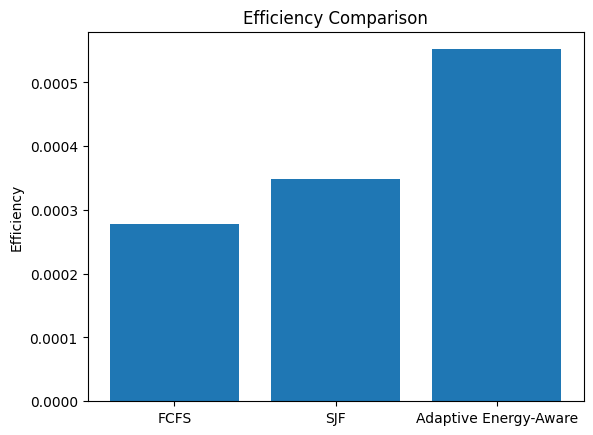

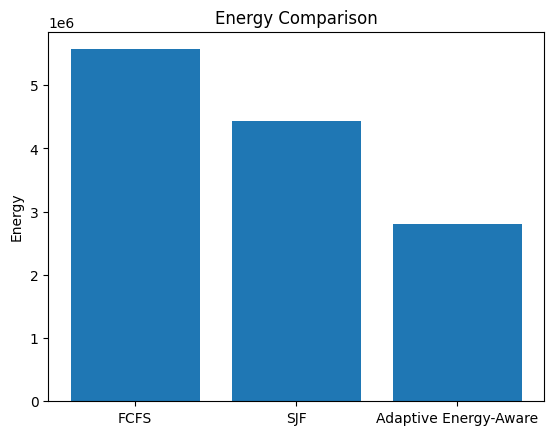

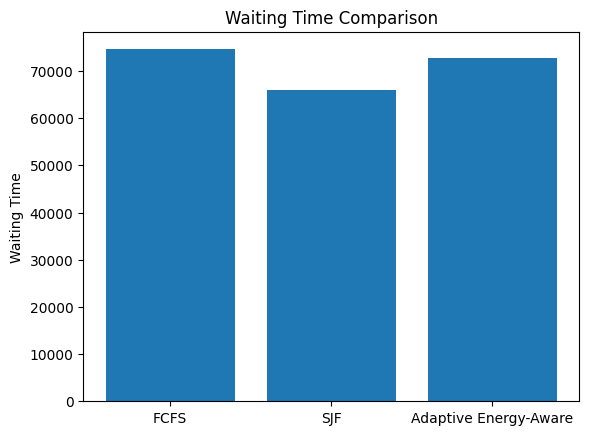

In [ ]:
import pandas as pd
import numpy as np
import time

from energy_predictor import predict_energy
from workload_analyzer import analyze_tasks
from anomaly_detector import detect_anomalies
from optimizer import optimize, fcfs, sjf, energy_aware
from autoscaler import scale_resources
from monitor import report
from simulation import run_simulation
from analytics import compute_efficiency

import matplotlib.pyplot as plt

def plot_gantt(timeline, title="Gantt Chart"):

    plt.figure()

    for i, task in enumerate(timeline):
        plt.barh(
            y=i,
            width=task["duration"],
            left=task["start"]
        )

    plt.xlabel("Time")
    plt.ylabel("Tasks")
    plt.title(title)
    plt.show()


N_ROWS = 5000
TASK_SAMPLE = 100

print("\n[INFO] Loading dataset...")
df = pd.read_csv("machine_usage.csv", nrows=N_ROWS, header=None)

df.columns = ["machine_id","timestamp","cpu","memory","c5","c6","c7","c8","c9"]
df = df[["cpu","memory"]]

df["cpu"] = pd.to_numeric(df["cpu"], errors='coerce')
df["memory"] = pd.to_numeric(df["memory"], errors='coerce')
df = df.dropna().reset_index(drop=True)

print("[INFO] Data loaded:", len(df), "rows")


print("\n[INFO] Generating execution time...")


df["execution_time"] = (
    df["cpu"] * np.random.uniform(0.05, 0.2, len(df)) +
    df["memory"] * np.random.uniform(0.02, 0.1, len(df)) +
    np.random.uniform(1, 10, len(df))
).astype(int) + 1

df["task_id"] = np.arange(len(df))

idx = np.random.choice(df.index, size=int(0.25*len(df)), replace=False)
df.loc[idx, "cpu"] = df.loc[idx, "cpu"] * 2.0


tasks = df.sample(TASK_SAMPLE).to_dict("records")
print("[INFO] Sampled tasks:", len(tasks))

print("\n[INFO] Analyzing workload...")
tasks = analyze_tasks(tasks)

print("[INFO] Detecting anomalies...")
anomalies = detect_anomalies(tasks)
print("[INFO] Anomalies found:", len(anomalies))

print("\n[INFO] Predicting future CPU load...")
predicted_cpu = predict_energy(df)
print("[INFO] Predicted CPU:", round(predicted_cpu,2))


print("\n[INFO] Allocating resources...")
resources = scale_resources(predicted_cpu)
print("[INFO] Resources allocated:", resources)


print("\n[INFO] Running base optimizer...")
waiting_base, energy_base = optimize(tasks)



print("\n[INFO] Running scheduling strategies...")

strategies = {
    "FCFS": fcfs,
    "SJF": sjf
}

results = {}


for name, strategy in strategies.items():

    start = time.time()

    waiting, energy, timeline = run_simulation(tasks, strategy)

    end = time.time()

    results[name] = {
        "waiting": waiting,
        "energy": energy,
        "efficiency": compute_efficiency(tasks, energy),
        "runtime": end - start
    }


start = time.time()

tasks_energy = energy_aware(tasks, resources)
waiting, energy, timeline = run_simulation(tasks_energy, lambda x: x)

end = time.time()
results["Adaptive Energy-Aware"] = {
    "waiting": waiting,
    "energy": energy,
    "efficiency": compute_efficiency(tasks, energy),
    "runtime": end - start,
    "timeline": timeline   
}

print("\n--- STRATEGY COMPARISON ---")

for name, res in results.items():
    print(f"\n{name}:")
    print(" Waiting Time:", res["waiting"])
    print(" Energy:", round(res["energy"],2))
    print(" Efficiency:", round(res["efficiency"],4))
    print(" Runtime:", round(res["runtime"],5))
    



def score(res):
    return (
        0.85 * res["energy"] +
        0.10 * res["waiting"] -
        0.05 * res["efficiency"]
    )

best = min(results, key=lambda x: score(results[x]))

print("\n BEST STRATEGY (SMART SCORE):", best)

print("\n--- SCORE BREAKDOWN ---")
for name, res in results.items():
    print(name, "-> Score:", round(score(res), 2))


save = False

if save:
    pd.DataFrame(results).to_csv("results.csv")
    print("[INFO] Results saved to results.csv")

print("\n[INFO] System execution complete.")




methods = list(results.keys())

energy = [results[m]["energy"] for m in methods]
waiting = [results[m]["waiting"] for m in methods]

efficiency = [results[m]["efficiency"] for m in methods]

plt.figure()
plt.bar(methods, efficiency)
plt.title("Efficiency Comparison")
plt.ylabel("Efficiency")
plt.show()


plt.figure()
plt.bar(methods, energy)
plt.title("Energy Comparison")
plt.ylabel("Energy")
plt.show()


plt.figure()
plt.bar(methods, waiting)
plt.title("Waiting Time Comparison")
plt.ylabel("Waiting Time")
plt.show()








